# Laboratorio de regresión - 2

## Significancia de factores

|                |   |
:----------------|---|
| **Nombre**     | Carlos Enrique Nieves Ochoa  |
| **Fecha**      | 31 de agosto de 2026  |
| **Expediente** | 758210  |

Descarga el archivo de publicidad y carga los datos (Advertising.csv).

# Carga de datos

In [8]:
import pandas as pd

df = pd.read_csv("advertising.csv")

print(df)

     Unnamed: 0     TV  radio  newspaper  sales
0             1  230.1   37.8       69.2   22.1
1             2   44.5   39.3       45.1   10.4
2             3   17.2   45.9       69.3    9.3
3             4  151.5   41.3       58.5   18.5
4             5  180.8   10.8       58.4   12.9
..          ...    ...    ...        ...    ...
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4

[200 rows x 5 columns]


**¿Hay alguna relación entre el presupuesto para publicidad y las ventas?**

Nuestra primera meta debe ser determinar si hay evidencia en los datos de que haya una asociación entre estas variables.

- ¿Por qué? ¿Qué resultaría si nos diéramos cuenta de la falta de relación entre el presupuesto de publicidad y las ventas?

Es la primera pregunta que hay que resolver porque de ella depende todo lo demás. Si en los datos no hubiera evidencia de una asociación entre el presupuesto de publicidad y las ventas, no tendría ningún caso construir un modelo para predecir ventas a partir de la publicidad, porque ese modelo no serviría para tomar decisiones. Lo que resultaría es que la recomendación al cliente sería dejar de gastar en publicidad (o al menos en estos medios), porque ese dinero no se estaría viendo reflejado en las ventas y estaría mejor invertido en otra cosa. Viendo los datos sí se alcanza a notar que a mayor presupuesto hay más ventas, pero eso hay que comprobarlo con números y no nada más a ojo.

**¿Qué tan fuerte es esta relación?**
Asumiendo que existe esta relación, ¿nos sirve conocer el impacto que tiene invertir en publicidad en las ventas?

Sí sirve, y mucho. Saber que la relación existe es apenas la mitad del trabajo; lo importante es saber qué tanto se mueven las ventas por cada peso extra que meto en publicidad, porque eso es lo que me deja decidir cuánto presupuesto asignar y a qué medio. Si la relación es fuerte, el modelo predice bien y puedo planear con confianza. Si es débil (aunque exista), significa que las ventas dependen más de otros factores y que meterle más dinero a la publicidad casi no mueve la aguja. Qué tan fuerte es la vamos a medir con el $R^2$, el RSE y los p-values de cada medio.

**¿Cuáles medios están asociados con las ventas? ¿Qué tan grande es la asociación entre un medio específico y las ventas?**

Hay 3 medios distintos en los datos. ¿Sirve invertir en los 3? ¿Conviene más invertir sólo en uno?

**¿Qué tan seguros estamos de que podríamos predecir ventas futuras?**

**¿La relación es lineal?**

**¿Hay sinergia entre estos medios?**

Puede ser que gastar \\$50,000 en publicidad y otros \\$50,000 en radio es mejor opción que gastar \\$100,000 en televisión. A esto le llamamos efecto de interacción.

Podemos usar regresión lineal para responder todas estas preguntas.

Realiza una regresión lineal:

$$ \text{ventas} \approx \beta_0 + (\beta_1)(\text{TV})$$

In [9]:
# Modelo de regresión sales ~ B0 + B1*TV

import numpy as np
from sklearn.linear_model import LinearRegression

x_v = df['TV'].values.reshape(-1, 1)      # Variable independiente
y_v = df['sales'].values.reshape(-1, 1)   # Variable dependiente

# Crear el modelo de regresión lineal
model = LinearRegression()
model.fit(x_v, y_v)

# Coeficientes del modelo
b0 = model.intercept_[0]   # Intercepto
b1 = model.coef_[0][0]     # Coeficiente de la variable independiente

R2 = model.score(x_v, y_v)

print(f"Modelo de regresión: sales = {b0:.6f} + {b1:.6f}*TV")
print(f"R²: {R2:.6f}")

Modelo de regresión: sales = 7.032594 + 0.047537*TV
R²: 0.611875


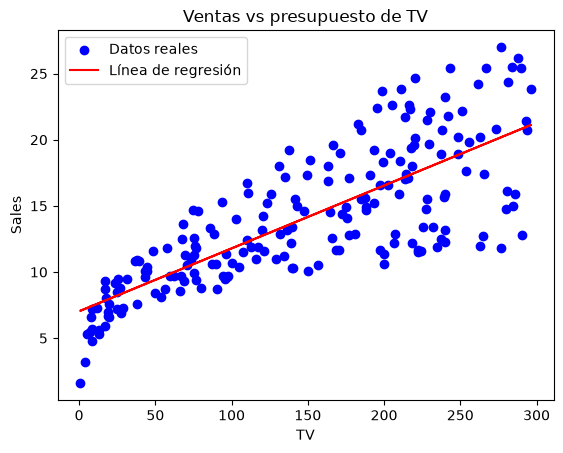

In [11]:
# Gráfica de los datos y la línea de regresión

import matplotlib.pyplot as plt

plt.scatter(df['TV'], df['sales'], color='blue', label='Datos reales')
plt.plot(x_v, model.predict(x_v), color='red', label='Línea de regresión')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('Ventas vs presupuesto de TV')
plt.legend()
plt.show()

El modelo queda **sales = 7.032594 + 0.047537(TV)**.

Como las ventas están en miles de unidades y el presupuesto en miles de dólares, cada 1,000 dólares extra invertidos en TV se asocian con unas 47.5 unidades más vendidas. El intercepto dice que sin gastar nada en TV se venderían alrededor de 7,032 unidades. El $R^2$ sale 0.6119, o sea que la TV por sí sola explica como el 61% de la variación de las ventas, nada mal, pero se nota que falta información.

### Verificando la precisión de nuestros coeficientes estimados

Recuerda que en el mundo real hay ruidos y errores de medición. Siempre se asume que la verdadera relación entre $X$ y $Y$ es $$Y = \beta_0 + \beta_1 X + \epsilon$$

Se asume que el término de error es independiente de $X$ (el error siempre es el mismo sin importar el valor de $X$). Este modelo describe a la *línea de regresión de la población*, que es la mejor aproximación de la verdadera relación entre $X$ y $Y$. Cuando usamos mínimos cuadrados encontramos la *línea de mínimos cuadrados*.

**¿Cuál es la diferencia entre población y muestra?**

La población es todo lo que en teoría podría medirse (todos los mercados, todas las campañas posibles), mientras que la muestra es nada más el pedacito que sí alcanzamos a medir.

**¿Cuál crees que sea la diferencia entre hacer una regresión con todos los datos de la población y una muestra de ella?**

Si tuviera la población completa, la recta que sale es la verdadera porque no habría incertidumbre ni error estándar que calcular, los coeficientes serían los reales y ya. Con una muestra, la recta sale parecida pero nunca idéntica.

La línea de regresión de la población no se puede observar. El concepto de comparar estas líneas es una extensión natural del acercamiento estadístico estándar de usar información de una muestra para estimar características de una población grande.

Imagina que quieres encontrar la altura promedio de un mexicano $\mu$. Medir a todos y cada uno de los mexicanos en situaciones similares, con la misma regla, mismo operador, y otras incontables formas de minimizar la variación de la medida es una tarea imposible. Lo que podemos asumir es que $\hat{\mu} = \bar{y}$. La media poblacional y la media muestral son diferentes, pero la media muestral es usualmente un buen estimado.

De la misma manera, como no contamos con el 100% de la información para hacer una regresión, los coeficientes $\beta_0$ y $\beta_1$ son desconocidos. Podemos estimarlos usando mínimos cuadrados, encontrando $\hat{\beta_0}$ y $\hat{\beta_1}$. Puede que las muestras que tengamos en ese momento estén un poco por encima de la media, pero otras muestras en otro momento puede que estén debajo de la media. En general, esperamos que el promedio de las aproximaciones $\hat{\mu}$ aproxime a $\mu$.

Esto lleva a la pregunta: ¿qué tan cercanos son nuestros coeficientes estimados a los verdaderos coeficientes? Utilizamos el concepto de error estándar para evaluar esto.

$$ \text{Var}(\hat{\mu})=\text{SE}(\hat{\mu})^2 = \frac{\sigma^2}{n} $$

Donde $\sigma$ es la desviación estándar de cada una de las observaciones $y_i$ de $Y$. El error estándar nos dice la cantidad promedio que el estimado difiere del valor verdadero. Podemos ver en la fórmula que entre más observaciones tengamos el error se hace más pequeño. Las fórmulas para errores estándar de $\hat{\beta_0}$ y $\hat{\beta_1}$ son:

$$ \text{SE}(\hat{\beta_0})^2 = \sigma^2 [\frac{1}{n} + \frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2}]$$

$$ \text{SE}(\hat{\beta_1})^2 = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2}$$

$$ \sigma^2 = \text{Var}(\epsilon) = \text{RSE}^2 = \frac{\text{RSS}}{n-p}$$

Para que estas fórmulas sean validas asumimos que los errores $\epsilon_i$ tienen varianza común $\sigma^2$ y que no están correlacionados.

Calcula los errores estándar de los coeficientes

In [12]:
# Errores estándar de los coeficientes (forma analítica)

n = len(x_v)   # Número de observaciones
p = 2          # Número de parámetros estimados (B0 y B1)

x_bar = np.mean(df['TV'])                # Media de la variable independiente
x_dis = np.sum((df['TV'] - x_bar) ** 2)  # Suma de (xi - x_bar)^2

E = df['sales'] - (b0 + b1 * df['TV'])   # Errores (residuales)
RSS = np.sum(E ** 2)                     # Residual sum of squares
sigma2 = RSS / (n - p)                   # Varianza de los errores (RSE^2)

SE_B0 = np.sqrt(sigma2 * (1/n + x_bar**2 / x_dis))   # Error estándar del intercepto
SE_B1 = np.sqrt(sigma2 / x_dis)                      # Error estándar del coeficiente

print(f"RSS: {RSS:.6f}")
print(f"RSE: {np.sqrt(sigma2):.6f}")
print(f"Error estándar del intercepto: {SE_B0:.6f}")
print(f"Error estándar del coeficiente: {SE_B1:.6f}")

RSS: 2102.530583
RSE: 3.258656
Error estándar del intercepto: 0.457843
Error estándar del coeficiente: 0.002691


Estos errores se pueden usar para calcular intervalos de confianza. Un intervalo de confianza del $95\%$ se define como un rango de valores en el cuál se encuentra el desconocido valor verdadero con un $95\%$ de probabilidad.

Otra forma de verlo es que si tomamos muestras repetidas y construimos un intervalo de confianza para cada una, el $95\%$ de los intervalos creados van a contener el valor verdadero. Para la regresión el intervalo de confianza del $95\%$ toma la forma:

$$ \hat{\beta_j} \pm 2\text{SE}(\hat{\beta_j})$$

Calcula los intervalos de confianza para los coeficientes estimados:

In [13]:
# Intervalos de confianza al 95%: Bj +/- 2*SE(Bj)

IC_B0 = [b0 - 2 * SE_B0, b0 + 2 * SE_B0]
IC_B1 = [b1 - 2 * SE_B1, b1 + 2 * SE_B1]

print(f"Intervalo de confianza al 95% para B0: [{IC_B0[0]:.6f}, {IC_B0[1]:.6f}]")
print(f"Intervalo de confianza al 95% para B1: [{IC_B1[0]:.6f}, {IC_B1[1]:.6f}]")

Intervalo de confianza al 95% para B0: [6.116908, 7.948279]
Intervalo de confianza al 95% para B1: [0.042155, 0.052918]


Los errores estándar también se usan para realizar pruebas de hipótesis. La prueba de hipótesis más común es probar la hipótesis nula de:

$$ H_0: \text{No hay relación entre } X \text{ y } Y \ \ \ \ (\beta_1=0)$$

contra la hipótesis alternativa:
$$ H_0: \text{Hay alguna relación entre } X \text{ y } Y \ \ \ (\beta_1 \neq 0)$$

**Explica con tus palabras el significado de la hipótesis nula y la hipótesis alternativa.**

La hipótesis nula es la aburrida, dice que TV y ventas no tienen nada que ver, que la pendiente verdadera es cero y que cualquier inclinación que yo vea en mis datos es pura casualidad de la muestra que me tocó. La alternativa, dice justo lo contrario, que sí existe alguna relación, sin importar si es positiva o negativa.

La idea es que siempre se arranca asumiendo que la nula es cierta, y sólo la descartamos si la evidencia (un estadístico t grande y un p-value chiquito) es lo suficientemente fuerte. Nunca "comprobamos" la nula, nada más la rechazamos o no la rechazamos.

Para probal la hipótesis nula debemos determinar si nuestro estimado $\hat{\beta_1}$ de $\beta_1$ está lo suficientemente alejado de cero para que podamos decir con confianza que este valor no es cero. 

¿Qué tan lejos? Depende de qué tanta confianza tengamos en el estimado encontrado. Si nuestro error estándar es pequeño y nuestro estimado está alejado de cero podríamos decir que hay muy poca probabilidad de que el valor verdadero sea 0. En cambio, si nuestro error estándar es grande y nuestro estimado está muy cerca de cero, entonces podrías ser que el valor verdadero sea cero y que no haya relación entre las variables.

Se calcula un *estadístico t* dado por
$$ t = \frac{\hat{\beta_j} - \mu}{\text{SE}(\hat{\beta_j})} $$

donde $\mu$ es el valor contra el que queremos probar.

Calcula el estadístico t para tus coeficientes estimados, usando como referencia la prueba de hipótesis.

In [14]:
# H0: No hay relación entre TV y sales (B1 = 0)
# H1: Sí hay relación entre TV y sales (B1 != 0)
# Se prueba contra mu = 0

mu = 0

t_b0 = (b0 - mu) / SE_B0   # Estadístico t del intercepto
t_b1 = (b1 - mu) / SE_B1   # Estadístico t del coeficiente

print(f"Estadístico t para B0: {t_b0:.6f}")
print(f"Estadístico t para B1: {t_b1:.6f}")

Estadístico t para B0: 15.360275
Estadístico t para B1: 17.667626


La distribución t tiene forma de campana y se parece bastante a la distribución normal cuando $n > 30$. Ya sólo es cuestión de calcular la probabilidad de observar cualquier número tal que su valor absoluto sea igual o mayor que el valor absoluto del estadístico t calculado. En otras palabras:
$$ P(|x| \geq |t|) $$

A esta probabilidad la llamamos *p-value*. Un *p-value* pequeño indica que es poco probable que exista por puro azar una relación significativa entre predictor y respuesta, en caso de que no haya una asociación real entre predictor y respuesta. En otras palabras, el *p-value* te dice la probabilidad de que parezca que hay relación cuando no la hay.

Si el *p-value* es pequeño, inferimos que sí hay una asociación entre el predictor y la respuesta, y **rechazamos la hipótesis nula**.
  

¿Qué tan pequeño? Depende de la aplicación. Un valor muy común es del $5\%$.

Utiliza el siguiente código para calcular el *p-value* para tus coeficientes

`from scipy import stats`

`p_bj = 2*(1 - stats.t.cdf(np.abs(t_bj), n-p))`

In [18]:
# p-values de los coeficientes

from scipy import stats

p_b0 = 2 * (1 - stats.t.cdf(np.abs(t_b0), n - p))
p_b1 = 2 * (1 - stats.t.cdf(np.abs(t_b1), n - p))

print(f"p-value de B0: {p_b0:.10f}")
print(f"p-value de B1: {p_b1:.10f}")

p-value de B0: 0.0000000000
p-value de B1: 0.0000000000


Los dos p-values salen `0.0000000000`, o sea que son tan chiquitos que ni siquiera alcanzan a imprimirse con 10 decimales

¿Se rechaza la hipótesis nula? ¿Qué significa?

Sí, se rechaza. Con un p-value muchísimo más chico que 0.05 no hay forma de sostener que $\beta_1 = 0$, así que concluimos que sí existe una relación entre lo que se gasta en publicidad de TV y las ventas.

Realiza otras dos regresiones. Ya tienes hecha la regresión de ventas dado el gasto en publicidad de TV. Realiza la regresión para gastos en radio y gastos en periódico. Organiza las respuestas para que debajo de esta celda se tenga:
- Título de regresión
- Coeficientes estimados
- Errores estándar de los coeficientes
- Intervalos de confianza
- Estadísticos t
- p-values
- Observaciones

Abajo está el mismo procedimiento que se hizo con TV, pero ahora para radio** y newspaper. Para no repetir el código tres veces armé una función que hace el proceso completo y lo imprime en el orden que se pide.

In [19]:
# Función que repite todo el procedimiento anterior para cualquier medio

def regresion_simple(medio):
    x_v = df[medio].values.reshape(-1, 1)      # Variable independiente
    y_v = df['sales'].values.reshape(-1, 1)    # Variable dependiente

    model = LinearRegression()
    model.fit(x_v, y_v)

    B0 = model.intercept_[0]
    B1 = model.coef_[0][0]

    n = len(x_v)
    p = 2

    x_bar = np.mean(df[medio])
    x_dis = np.sum((df[medio] - x_bar) ** 2)

    RSS = np.sum((df['sales'] - (B0 + B1 * df[medio])) ** 2)
    sigma2 = RSS / (n - p)

    SE_B0 = np.sqrt(sigma2 * (1/n + x_bar**2 / x_dis))
    SE_B1 = np.sqrt(sigma2 / x_dis)

    t_B0 = B0 / SE_B0
    t_B1 = B1 / SE_B1

    p_B0 = 2 * (1 - stats.t.cdf(np.abs(t_B0), n - p))
    p_B1 = 2 * (1 - stats.t.cdf(np.abs(t_B1), n - p))

    print(f"REGRESIÓN DE VENTAS DADO EL GASTO EN {medio.upper()}")
    print(f"Modelo: sales = {B0:.6f} + {B1:.6f}*{medio}")
    print()
    print("Coeficientes estimados")
    print(f"   B0 = {B0:.6f}")
    print(f"   B1 = {B1:.6f}")
    print("Errores estándar de los coeficientes")
    print(f"   SE(B0) = {SE_B0:.6f}")
    print(f"   SE(B1) = {SE_B1:.6f}")
    print("Intervalos de confianza al 95%")
    print(f"   B0: [{B0 - 2*SE_B0:.6f}, {B0 + 2*SE_B0:.6f}]")
    print(f"   B1: [{B1 - 2*SE_B1:.6f}, {B1 + 2*SE_B1:.6f}]")
    print("Estadísticos t")
    print(f"   t(B0) = {t_B0:.6f}")
    print(f"   t(B1) = {t_B1:.6f}")
    print("p-values")
    print(f"   p(B0) = {p_B0:.10f}")
    print(f"   p(B1) = {p_B1:.10f}")
    print()
    print(f"RSE: {np.sqrt(sigma2):.6f}")
    print(f"R²: {model.score(x_v, y_v):.6f}")

    return model

## Regresión de ventas dado el gasto en publicidad de radio

In [20]:
model_radio = regresion_simple('radio')

REGRESIÓN DE VENTAS DADO EL GASTO EN RADIO
Modelo: sales = 9.311638 + 0.202496*radio

Coeficientes estimados
   B0 = 9.311638
   B1 = 0.202496
Errores estándar de los coeficientes
   SE(B0) = 0.562900
   SE(B1) = 0.020411
Intervalos de confianza al 95%
   B0: [8.185837, 10.437439]
   B1: [0.161673, 0.243318]
Estadísticos t
   t(B0) = 16.542245
   t(B1) = 9.920765
p-values
   p(B0) = 0.0000000000
   p(B1) = 0.0000000000

RSE: 4.274944
R²: 0.332032


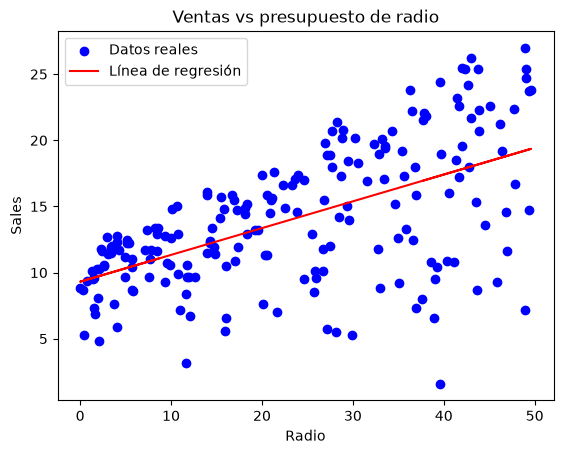

In [21]:
# Gráfica de la regresión de radio

x_radio = df['radio'].values.reshape(-1, 1)

plt.scatter(df['radio'], df['sales'], color='blue', label='Datos reales')
plt.plot(x_radio, model_radio.predict(x_radio), color='red', label='Línea de regresión')
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.title('Ventas vs presupuesto de radio')
plt.legend()
plt.show()

#### Observaciones (radio)

- El modelo queda sales = 9.311638 + 0.202496(radio), por lo que cada 1,000 dólares invertidos en radio se asocian con unas 202 unidades más vendidas, o sea que por dólar rinde bastante más que la TV (47.5 unidades).
- El p-value de $\hat{\beta_1}$ es prácticamente 0 y el intervalo de confianza [0.161673, 0.243318] no pasa por cero, así que se rechaza la hipótesis nula: el radio sí está asociado con las ventas.
- Aun así el $R^2$ es de sólo 0.3320, o sea que el radio por sí solo explica apenas el 33% de la variación de las ventas, bastante menos que TV (61%). El error estándar de la pendiente (0.020411) es proporcionalmente más grande, y por eso el estadístico t (9.920765) queda más chico que el de TV (17.667626).

## Regresión de ventas dado el gasto en publicidad de newspaper

In [22]:
model_newspaper = regresion_simple('newspaper')

REGRESIÓN DE VENTAS DADO EL GASTO EN NEWSPAPER
Modelo: sales = 12.351407 + 0.054693*newspaper

Coeficientes estimados
   B0 = 12.351407
   B1 = 0.054693
Errores estándar de los coeficientes
   SE(B0) = 0.621420
   SE(B1) = 0.016576
Intervalos de confianza al 95%
   B0: [11.108567, 13.594247]
   B1: [0.021542, 0.087845]
Estadísticos t
   t(B0) = 19.876096
   t(B1) = 3.299591
p-values
   p(B0) = 0.0000000000
   p(B1) = 0.0011481959

RSE: 5.092480
R²: 0.052120


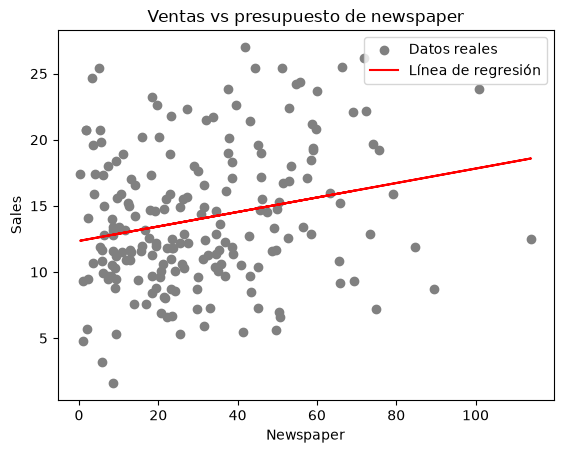

In [23]:
# Gráfica de la regresión de newspaper

x_newspaper = df['newspaper'].values.reshape(-1, 1)

plt.scatter(df['newspaper'], df['sales'], color='grey', label='Datos reales')
plt.plot(x_newspaper, model_newspaper.predict(x_newspaper), color='red', label='Línea de regresión')
plt.xlabel('Newspaper')
plt.ylabel('Sales')
plt.title('Ventas vs presupuesto de newspaper')
plt.legend()
plt.show()

#### Observaciones (newspaper)

- El modelo queda sales = 12.351407 + 0.054693(newspaper).
- El p-value de $\hat{\beta_1}$ es 0.0011481959, que sí es menor a 0.05, y el intervalo [0.021542, 0.087845] tampoco toca el cero, así que por sí sola la inversión en periódico también sale significativa y se rechazaría la hipótesis nula.
- Pero el $R^2$ es de apenas 0.0521: el periódico explica como el 5% de la variación de las ventas, o sea casi nada. Su estadístico t (3.299591) es mucho más chico que el de TV (17.67) y el de radio (9.92), y el RSE de 5.0925 es el más alto de los tres modelos.
- Comparando los tres medios: TV es el que más explica ($R^2$ = 0.6119), radio le sigue ($R^2$ = 0.3320) y newspaper apenas aporta ($R^2$ = 0.0521).

## Regresión lineal múltiple

En lugar de hacer una regresión para cada factor independiente, quizás se puede extender el modelo para que tenga varios factores dentro:

$$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p + \epsilon $$

Para nuestro ejemplo de publicidad:

$$ \text{sales} = \beta_0 + \beta_1 (\text{TV}) + \beta_2 (\text{radio}) + \beta_3 (\text{newspaper}) + \epsilon $$

Utiliza la librería `statsmodels` para realizar la regresión. Por defecto la librería statsmodels no toma en cuenta el intercepto ($\beta_0$), por lo que se tendrá que agregar una columna de unos de tamaño *n* a la matriz X.

`import statsmodels.api as sm`

`ols = sm.OLS(Y, X)`

`results = ols.fit()`

`results.summary()`

In [24]:
# Regresión lineal múltiple: sales ~ B0 + B1*TV + B2*radio + B3*newspaper

import statsmodels.api as sm

Y = df['sales']                            # Variable dependiente
X_v = df[['TV', 'radio', 'newspaper']]     # Variables independientes

# statsmodels no toma en cuenta el intercepto, hay que agregar la columna de unos de tamaño n
ones = np.ones([df.shape[0], 1])
X = np.hstack([ones, X_v.values])
X = pd.DataFrame(X, columns=['intercepto', 'TV', 'radio', 'newspaper'])

ols = sm.OLS(Y, X)
results = ols.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:              dom., 30 ago. 2026   Prob (F-statistic):           1.58e-96
Time:                        21:26:20   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercepto     2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
radio          0.1885      0.009     21.893      0.000       0.172       0.206
newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

El modelo múltiple queda:

$$ \text{sales} = 2.938889 + 0.045765(\text{TV}) + 0.188530(\text{radio}) - 0.001037(\text{newspaper}) $$

El $R^2$ sube a 0.897 ($R^2$ ajustada de 0.896) y el estadístico F es de 570.3 con un p-value casi cero, así que el modelo completo explica las ventas muchísimo mejor que cualquiera de las regresiones simples. Lo que más salta a la vista es que newspaper deja de ser significativo (p = 0.860) e incluso su coeficiente sale negativo, mientras que TV y radio se mantienen fuertísimos.

¿Qué diferencias puedes observar entre los *p-values* de una regresión múltiple y los encontrados en las regresiones simples? ¿Por qué crees que existen estas diferencias?

In [25]:
# Matriz de correlación, para entender por qué cambian los p-values

df[['TV', 'radio', 'newspaper', 'sales']].corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


La diferencia más grande está en newspaper: en la regresión simple su p-value era 0.0011 (significativo) y en la múltiple se va hasta 0.8599, o sea que deja de servir por completo. TV y radio siguen significativos en las dos, pero en la múltiple sus p-values son todavía más chicos y sus estadísticos t crecen bastante (TV pasa de t = 17.67 a t = 32.81).

¿Por qué pasa esto?

1. **Newspaper está correlacionado con radio** (la correlación entre las dos es de 0.354). En los mercados donde se gasta mucho en radio también se tiende a gastar mucho en periódico. Como la regresión simple sólo ve una variable a la vez, el periódico se "cuelga" del efecto del radio y parece que él está vendiendo, cuando en realidad quien mueve las ventas es el radio. En cuanto metemos radio al modelo, newspaper ya no aporta nada nuevo y su coeficiente se cae a casi cero.
2. **El modelo múltiple explica mucho mejor los datos**, así que el error que queda sin explicar es mucho más chico: el RSE baja de 3.2587 (modelo sólo con TV) a 1.6855. Como el RSE es lo que alimenta las fórmulas de los errores estándar, los SE se achican, y al achicarse los SE los estadísticos t crecen y los p-values se hacen todavía más pequeños para TV y radio.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3

## Addendum

Para calcular los *p-values* de los parámetros sin `statsmodels`:
1. Calcular RSS
2. Calcular RSE
3. `var_beta = np.linalg.inv(X.T @ X) * rse**2` (X con columna de intercepto)
4. `std_beta = np.sqrt(var_beta.diagonal())` El orden de los valores corresponde al orden de los factores en las columnas de la matriz $X$.
5. Calcular *estadístico t*
6. Calcular *p-value*